<a href="https://colab.research.google.com/github/Viggo-Kristensen/kaggle-competitions/blob/main/stellar_class_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Problem Definition**

### Classify stars, galaxies and quasars based on their spectral characteristics

## **Imports**

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 4.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import os
import optuna

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import balanced_accuracy_score
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

import optuna.visualization as vis

## **Dataset**

The dataset consists of rows of cosmic objects where for each datapoint spectral characteristics are stated. Features included in the dataset are `redshift`, `g`, `z`, `alpha`, `delta` and more. The dataset is synthetically generated from another dataset `Stellar Classification Dataset - SDSS1`. The feature distributions are close to, but not the same, as the original, meaning it is unclear whether or not it is worth it to use it in training.

### Uploading Files

In [3]:
!mkdir -p /root/.kaggle
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [4]:
# upload kaggle.json ONCE
from google.colab import files
files.upload()

!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c playground-series-s6e6

Saving kaggle.json to kaggle.json
100% 58.6M/58.6M [00:00<00:00, 120MB/s]



### Unzipping Files

In [5]:
!unzip -q playground-series-s6e6.zip -d data

### Creating Dataframes

In [6]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

In [7]:
target = "class"
drop_cols = [target, "id"]
X = train.drop(columns=drop_cols)
y=train[target]



## **Feature Engineering**

In [8]:
class AddFeatures(BaseEstimator, TransformerMixin):
  def fit(self, X, y=None):
    return self

  def transform(self, X):
    X = X.copy()

    # add features
    X["redshift_mul_g"] = X["redshift"] * X["g"]
    X["redshift_frac_g"] = X["redshift"] / X["g"]

    return X


In [9]:
X_fe = AddFeatures().transform(X)

num_cols = X_fe.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_fe.select_dtypes(include=["object", "bool"]).columns

le = LabelEncoder()
y_encoded = le.fit_transform(y)

## **Preprocessing**

### Numerical transformer

In [10]:
numerical_transformer = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
])

### Categorical transformer

In [11]:
categorical_transformer = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

### Preprocessor

In [12]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

## **Pipeline**

In [13]:
def build_model(**params):

    num_classes = len(np.unique(y_encoded))

    model = Pipeline([
        ("feature engineering", AddFeatures()),
        ("preprocessing", preprocessor),
        ("classifier", XGBClassifier(
            **params,
            objective="multi:softprob",
            num_class=num_classes,
            eval_metric="mlogloss",
            tree_method="hist",
            random_state=42
        ))
    ])

    return model

## **Hyperparameter Optimization**

In [14]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 0, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 10),
        "gamma": trial.suggest_float("gamma", 0, 10),
    }

    model = build_model(**params)

    scores = cross_val_score(
        model,
        X,
        y_encoded,
        cv=3,
        scoring="balanced_accuracy",
        n_jobs=-1
    )

    return scores.mean()

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

best_params = study.best_params
best_value = study.best_value

print("best params: ", best_params)
print("best value: ", best_value)

### Optuna results visualisation

Optimization history plot

In [ ]:
vis.plot_optimization_history(study)

Hyperparameter Importance

In [ ]:
vis.plot_param_importances(study)

Parallel Coordinate Plot

In [ ]:
vis.plot_parallel_coordinate(study)

### Best hyperparameters

In [16]:
best_params = {
    'n_estimators': 794,
    'max_depth': 9,
    'learning_rate': 0.0823996397246956,
    'colsample_bytree': 0.8931237232735324,
    'min_child_weight': 3.460805312360754,
    'subsample': 0.6461986790692312,
    'reg_lambda': 5.406553897124582,
    'reg_alpha': 0.16001098431114888,
    'gamma': 0.689746535556626}

## **Model**

In [17]:
model = build_model(**best_params)

## **Feature Engineering Validation (CV Evaluation)**

In [ ]:
scores_fe = cross_val_score(
    model,
    X,
    y_encoded,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1

)

print("scores_fe:", scores_fe)
print("mean score:", scores_fe.mean())

scores_fe: [0.95608269 0.9553785  0.95571122 0.95705343 0.95726701]
mean score: 0.9562985711136023


scores_fe: [0.95608269 0.9553785  0.95571122 0.95705343 0.95726701]
mean score: 0.9562985711136023

## **Training**

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

Pipeline(steps=[('feature engineering', AddFeatures()),
                ('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'redshift_mul_g',
       'redshift_frac_g', 'redshift_min_g'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy...
                               gamma=0.689746535556626, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.0823996397246956, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=9,
                               max_leaves=None,
                               min_child_weight=3.460805312360754, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=794, n_jobs=None, num_class=3, ...))])

## **Permutation Importance**

In [ ]:
result = permutation_importance(
    model,
    X_val,
    y_val,
    n_repeats=3,
    scoring="balanced_accuracy",
)

perm_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance": result.importances_mean
}).sort_values("importance", ascending=False)

print(perm_df.head(15))

## **Evaluation**

### Balanced accuracy score

In [ ]:
y_preds = model.predict(X_val)
balanced_accuracy_score(y_val, y_preds)

np.float64(0.9575706538191161)

### Confusion Matrix

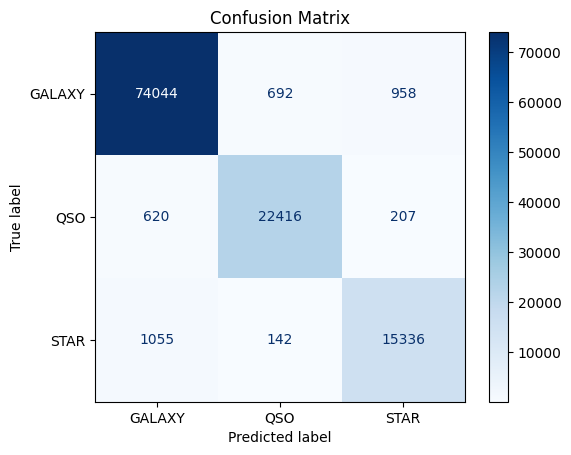

In [ ]:
cm = confusion_matrix(y_val, y_preds)
class_names = le.classes_
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

## **Final Training**

In [18]:
model.fit(X, y_encoded)

Pipeline(steps=[('feature engineering', AddFeatures()),
                ('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'redshift_mul_g',
       'redshift_frac_g'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')...
                               gamma=0.689746535556626, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.0823996397246956, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=9,
                               max_leaves=None,
                               min_child_weight=3.460805312360754, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=794, n_jobs=None, num_class=3, ...))])

## **Submission**

In [19]:
submission = pd.read_csv("data/sample_submission.csv")
submission["class"] = model.predict(test)

submission["class"] = submission["class"].replace({
    0: 'GALAXY',
    1: 'QSO',
    2: 'STAR'
})

submission.to_csv("submission.csv", index=False)

## **Reflections**

**Notes**


*   Through the permutation importance analysis it has been deducted that the most useful predictors for the model are `redshift` and `g`.
*   The hyperparameter importance plot showed that the objective function was most sensitive to the gamma value which ended up having an optimal value at 0.002. This suggests that the model hurts a lot from pruning and it is advantageous to keep splits with small gains.


**What i learned**


*   How to use labelencoding for XGBCLassifier
*   How to use Optuna to find optimal hyperparameters
*   How XGBoost works for multiple classes



